### Data prerocessing

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

Loading the training data and class labels

In [3]:
# Code sources:
# https://stackoverflow.com/questions/33503993/read-in-all-csv-files-from-a-directory-using-python
# https://stackoverflow.com/questions/5137497/find-the-current-directory-and-files-directory
# https://stackoverflow.com/questions/9572490/find-index-of-last-occurrence-of-a-substring-in-a-string

def loadData(datatype):

    X_data = []
    y_data = []

    # Directory path to the data
    directory_path = os.path.abspath(os.path.join(os.getcwd(),'..',datatype))

    # print(path)
    print(directory_path)

    for filename in glob.glob(os.path.join(directory_path, '*.csv')):

        # print(filename.rindex('_0'))
        # print(filename[filename.rindex('_0')-1])

        # Extracting the class labels from the filenames
        y = int(filename[filename.rindex('_0')-1])
        y_data.append(y)

        # Read the csv data file and convert into numpy array
        x = np.genfromtxt(filename, delimiter=',')
        X_data.append(x)


    # X_data = np.array(X_data[0])
    # X_data
    # print(X_data.shape)

    # Checking classes and their counts
    values, counts = np.unique(y_data, return_counts=True)

    print(f'The data has {len(X_data)} samples with {values} classes and respectively their counts {counts}.')

    return X_data, y_data

X_train_init, y_train_init = loadData('training_data')


c:\Users\heikk\Desktop\PRML_HT\training_data
The data has 1000 samples with [0 1 2 3 4 5 6 7 8 9] classes and respectively their counts [100 100 100 100 100 100 100 100 100 100].


In [4]:
X_train_std = [] # Standardized training data
eigenvalues = []
eigenvectors = []
T_train = [] # Projection training data

# print(X_train)

for i in range(len(X_train_init)):
    X = X_train_init[i]
    # Standardization Z = (X-µ) / σ
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=1)
    Z = (X - mu) / sigma
    X_train_std.append(Z)

In [5]:
new_X_train = []

# Extracting features from the previous training data and making a simpler dataset with class labels
for i in range(len(X_train_std)):

    x = X_train_std[i]
    sum = x.sum()
    mean = x.mean()
    median = np.median(x)
    std = x.std()
    max = x.max()
    min = x.min()

    X = [sum, mean, median, std, max, min]
    new_X_train.append(X)

final_y = np.array(y_train_init) # no column vector
final_X = np.array(new_X_train) # keeping them separate 

# Multinomial Logistic Regression model:

In [6]:
def sumHelper(N,K,z):
    Sum_k = np.zeros((N,1))
    for i in range(N): # maybe this could be vectorized too in numpy
        sum2 = 0
        for k in range(K):
            sum2 = sum2 + np.exp(z[i,k])
        Sum_k[i, 0] = sum2
    return Sum_k

def MLR_test(W, X_te):
    N,D = X_te.shape
    K = 10
    x0 = np.ones((N,1)) # column of ones
    x_bias = np.concatenate([X_te,x0], axis=1) # (N,D+1), adding to the end

    z = x_bias @ W.T # (200,10), (N,K)

    Sum = sumHelper(N,K,z)

    # y = softmax(z)
    # y_k = e^(z_k) / Sum_(k') [e^(z_k')]
    y = np.exp(z) / Sum # using the weights (+bias) to get a row vector (10 in length) for each class which represents a probability ...
    #print(y.shape) # (200,10)
    predicted = y.argmax(axis=1) # ... and then taking the index value of the maximum probability, which is thus the predicted class
    #print(predicted.shape) # (200,)
    return predicted

c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

              precision    recall  f1-score   support

           0       0.29      0.10      0.15        20
           1       0.34      0.50      0.41        20
           2       0.20      0.05      0.08        20
           3       0.28      0.40      0.33        20
           4       0.67      0.10      0.17        20
           5       0.44      0.40      0.42        20
           6       0.00      0.00      0.00        20
           7       0.28      0.40      0.33        20
           8       0.41      0.35      0.38        20
           9       0.27      0.85      0.41        20

    accuracy                           0.32       200
   macro avg       0.32      0.32      0.27       200
weighted avg       0.32      0.32      0.27       200



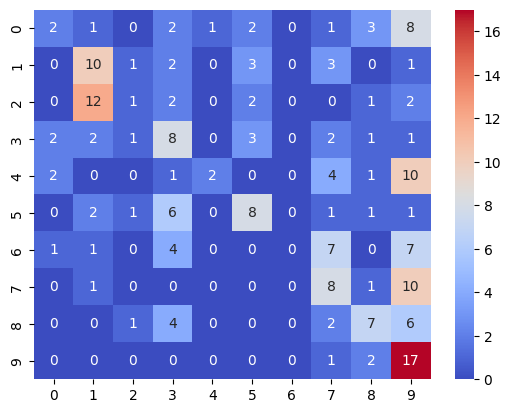

In [ ]:
# input: X_train (feature data), y_train (class value vector)
# with these we want to train the MLR model, which means maximizing the likelihood of each parameter that makes a specific class appear

# output: trained weights and biases for each class, such that the accuracy converges or is maximized during training, ideally

# https://www.cs.toronto.edu/~rahulgk/courses/csc311_f22/lectures/lec05_annotated_alicegao.pdf : Slide 10 most useful

# https://www.youtube.com/watch?v=hYBwBmojXoU some emotional support and making the indices understandable
# video in slide format: https://www.kamperh.com/data414/slides/multiclass_logistic_regression-crop.pdf : Slides 2-9 most useful

# https://web.stanford.edu/~jurafsky/slp3/old_aug24/5.pdf : a more formal source, not used for this (yet?)

def MLR_train(X_tr, y_tr, alpha, gradientDescentIterations):
    N,D = X_tr.shape
    K = 10
    # D = number of features in our feature matrix X_tr
    # K = number of classes (hardcoded to 10)
    # N = number of samples in total (800 now since we are splitting the data to 80/20)
    #
    # loop indices:
    # n loops through the samples (N)
    # k loops through the classes (K)

    x0 = np.ones((N,1)) # column of ones
    x = np.concatenate([X_tr,x0], axis=1) # (N,D+1), adding to the end for the bias term

    W = np.zeros((K,D+1)) # weight matrix initialization. Rows -> K (10), Columns -> D + 1 (feature number (now it is 6) + 1 bias) => 7

    t = np.zeros((N, K)) # the one-hot vectors in a matrix, columns correspond to each class: (N,K)
    t[np.arange(N), y_tr] = 1.0 # https://stackoverflow.com/questions/29831489/convert-array-of-indices-to-one-hot-encoded-array-in-numpy 

    while gradientDescentIterations > 0: # could apply other break conditions here too...
        # z = Wx (bias version)
        z = x @ W.T # logits (N,K):(800,10)

        Sum = sumHelper(N,K,z)
        # y = softmax(z)
        # y_k = e^(z_k) / Sum_(k') [e^(z_k')]
        y = np.exp(z) / Sum

        # gradient descent, updating each class's weights + bias:
        # wk <- wk − alpha * (1/N) * (N)∑(n=1) [ (y_k^n − t_k^n ] * x(n)
        # NOTE: This should probably be vectorised. Currently these (python) loops are inefficient...
        for k in range(K):
            # we are going row by row down W, which means we are optimizing the weights (+bias) for each class (k) one at a time...
            gradientSum_k = np.zeros(D+1)
            for n in range(N):
                # (N)∑(n=1) [ (y_k^n − t_k^n ] * x(n); predicted (y), true(t). Class-specific probabilities in (y), and the one-hot columns in (t) correspond to the same classes...
                gradientSum_k = gradientSum_k + (y[n,k] - t[n,k]) * x[n,:]
                # row (n), column (k)

            # wk <- wk − alpha * (1/N) * gradientSum_k
            W[k,:] = W[k,:] - alpha * (1/N) * gradientSum_k # updating class-specific weights one at a time to the column

        gradientDescentIterations = gradientDescentIterations - 1

    return W # in all essence, this function returns the weights (and the bias) for each class, such that class1 is a row vector at the top, class 2 the second row vector and so on.

# standard train/test split with premade function
X_train, X_test, y_train, y_test = train_test_split(final_X, final_y, test_size=0.2, stratify=final_y,random_state=42) # currently always the same test/train sets to see how changing the alpha
                                                                                                                       # and gradientDescentIterations affects things...

W = MLR_train(X_train, y_train, alpha = 0.5, gradientDescentIterations = 200)
# training the weights of the model, W is a vector, and for each index, it contains 6(feature weights) + 1(bias)
# NOTE: we could also apply some L2 regularization or something, would likely improve the metrics
# NOTE: should probably apply some way to check accuracy mid-training, and make sure we do not overfit either
# NOTE: i might have done the scaling wrong (?)
# NOTE: in this code we are still accepting rows of zeros in the raw data
y_pred = MLR_test(W, X_test)

CR_RF = classification_report(y_test, y_pred)
CM_RF = confusion_matrix(y_test, y_pred)
print(CR_RF)
sns.heatmap(CM_RF, annot=True, cmap = "coolwarm")
plt.show()

c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

              precision    recall  f1-score   support

           0       0.29      0.10      0.15        20
           1       0.34      0.50      0.41        20
           2       0.20      0.05      0.08        20
           3       0.28      0.40      0.33        20
           4       0.67      0.10      0.17        20
           5       0.44      0.40      0.42        20
           6       0.00      0.00      0.00        20
           7       0.28      0.40      0.33        20
           8       0.41      0.35      0.38        20
           9       0.27      0.85      0.41        20

    accuracy                           0.32       200
   macro avg       0.32      0.32      0.27       200
weighted avg       0.32      0.32      0.27       200



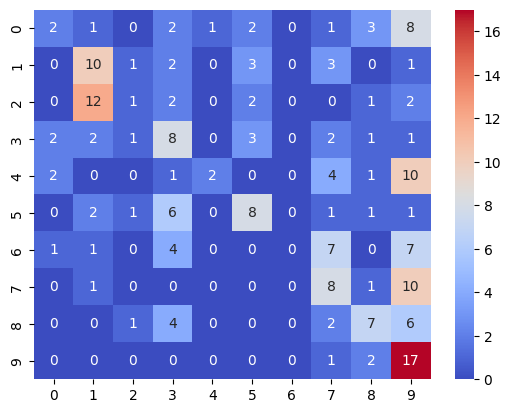

In [8]:
# for testing the speed of this separate function, this is mostly what will matter if the teacher uses this
y_pred = MLR_test(W, X_test)

CR_RF = classification_report(y_test, y_pred)
CM_RF = confusion_matrix(y_test, y_pred)
print(CR_RF)
sns.heatmap(CM_RF, annot=True, cmap = "coolwarm")
plt.show()

# Testing a premade Multinomial Logistic Regression model:

c:\Users\heikk\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.18      0.15      0.16        20
           1       0.46      0.60      0.52        20
           2       0.14      0.15      0.15        20
           3       0.40      0.30      0.34        20
           4       0.07      0.05      0.06        20
           5       0.27      0.20      0.23        20
           6       0.00      0.00      0.00        20
           7       0.32      0.60      0.42        20
           8       0.25      0.25      0.25        20
           9       0.46      0.65      0.54        20

    accuracy                           0.29       200
   macro avg       0.26      0.29      0.27       200
weighted avg       0.26      0.29      0.27       200



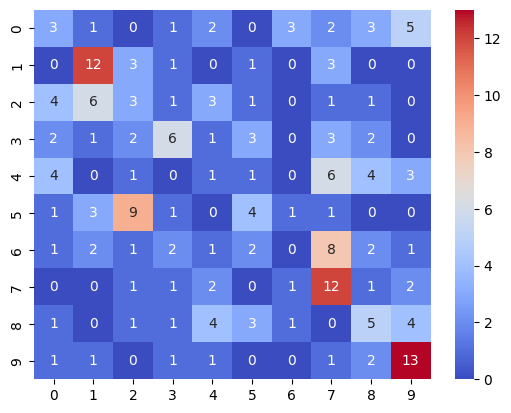

In [9]:
X_train, X_test, y_train, y_test = train_test_split(final_X, final_y, test_size=0.2, stratify=final_y)

# using a premade model just to get an idea of the current features

model = LogisticRegression(multi_class="multinomial", solver="lbfgs", penalty="l2", max_iter=2000, random_state=42) # varies between 0.2-0.3
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

CR_RF = classification_report(y_test, y_pred)
CM_RF = confusion_matrix(y_test, y_pred)
print(CR_RF)
sns.heatmap(CM_RF, annot=True, cmap = "coolwarm")
plt.show()

# Testing a Bayesian One-Vs-Rest premade model:

              precision    recall  f1-score   support

           0       0.31      0.20      0.24        20
           1       0.69      0.45      0.55        20
           2       0.32      0.30      0.31        20
           3       0.22      0.35      0.27        20
           4       0.44      0.20      0.28        20
           5       0.36      0.20      0.26        20
           6       0.15      0.20      0.17        20
           7       0.33      0.55      0.42        20
           8       0.38      0.30      0.33        20
           9       0.63      0.85      0.72        20

    accuracy                           0.36       200
   macro avg       0.38      0.36      0.35       200
weighted avg       0.38      0.36      0.35       200



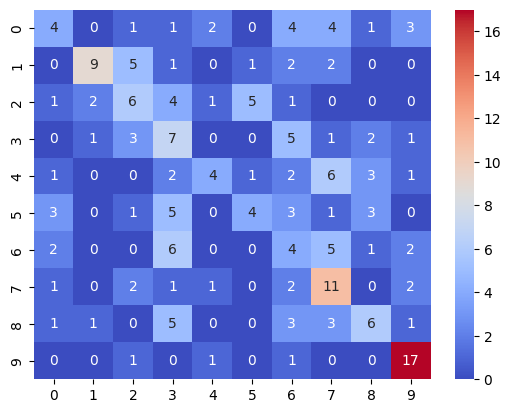

In [10]:
# might as well test some bayesian one vs rest model too:
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier

X_train, X_test, y_train, y_test = train_test_split(final_X, final_y, test_size=0.2, stratify=final_y) # random data

# using a premade model just to get an idea of the current features

model = OneVsRestClassifier(GaussianNB()) # varies between 0.25-0.4
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

CR_RF = classification_report(y_test, y_pred)
CM_RF = confusion_matrix(y_test, y_pred)
print(CR_RF)
sns.heatmap(CM_RF, annot=True, cmap = "coolwarm")
plt.show()